# [실습 11-1] LSTM 시퀀스 학습 — 긴 문맥과 기울기의 생존

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 가능, GPU 권장) |
| 본문 연계 | 11.2 장기 의존성 문제 직결 |
| 선수 실습 | [실습 9-2] (Keras 사용법) |
| 준비 | 부록 B.1·B.3 참고 |

"문장 첫머리의 단서를 끝까지 기억해야 하는" 상황을 가장 작은
합성 과제로 만들어, ① 문맥 창이 정보를 놓치면 어떤 모델도 못
푼다는 것과 ② 학습 신호(기울기)가 시간을 거슬러 얼마나
살아남는지를 **직접 측정**한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch11/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from utils import plot_style

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("TensorFlow", tf.__version__)

import keras
keras.utils.set_random_seed(11)
tf.config.experimental.enable_op_determinism()
# 완전 결정성(저장소 전용) — 기울기 측정·학습
# 수치가 실행마다 완전히 같도록 고정한다

Python 3.12.6
TensorFlow 2.21.0


### [셀 1] 과제 정의 — 첫 토큰을 기억하라 📖

In [2]:
rng = np.random.default_rng(11)

def make_data(gap, n=3000, vocab=8):
    """첫 토큰(1 또는 2)이 정답 라벨. 그 뒤에는
    무관한 잡음 토큰(3~7)이 gap개 이어진다."""
    signal = rng.integers(1, 3, n)          # 1 또는 2
    noise = rng.integers(3, vocab, (n, gap))
    X = np.concatenate([signal[:, None], noise],
                       axis=1)
    y = signal - 1                          # 0 또는 1
    return X, y

X, y = make_data(gap=50)
print("시퀀스 형태:", X.shape, "— 길이 51")
print("예시:", X[0][:8], "... 정답:", y[0])

시퀀스 형태: (3000, 51) — 길이 51
예시: [1 4 6 6 4 7 3 4] ... 정답: 0


**핵심 포인트**
- "그 영화 재미없었어. …(50단어)… 그래서 나는 ___였다"의 뼈대만 남긴 과제다 — 첫머리 단서 하나가 마지막 판단을 결정한다(11.2의 장기 의존성).
- 시드 고정으로 항상 같은 데이터가 재현된다.

기대 출력: 시퀀스 형태 (3000, 51)

### [셀 2] LSTM으로 학습 — 51스텝 전 단서를 기억한다 📖

In [3]:
def build_lstm(vocab=8):
    tf.random.set_seed(11)
    m = keras.Sequential([
        keras.layers.Embedding(vocab, 8),
        keras.layers.LSTM(16),
        keras.layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])
    return m

lstm = build_lstm()
lstm.fit(X[:2400], y[:2400], epochs=15,
         batch_size=64, verbose=0)
acc = lstm.evaluate(X[2400:], y[2400:], verbose=0)[1]
print(f"gap=50 평가 정확도: {acc:.0%}")

E0000 00:00:1784199004.924372 153471574 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


gap=50 평가 정확도: 100%


**핵심 포인트**
- 정답 단서와 판단 사이가 50스텝 — LSTM은 셀 상태(장기 기억 벨트)에 첫 토큰을 실어 끝까지 운반한다(11.2 LSTM 게이트).

기대 출력: `gap=50 평가 정확도: 100%`

실패 시 대처: 정확도가 50% 부근이면 학습 실패(무작위 추측) — 시드 셀부터 재실행한다.

### [셀 3] 문맥 절단 실험 — 창 밖의 정보는 누구도 못 본다 📖

In [4]:
# 같은 데이터에서 마지막 10토큰만 보여 주면?
X_cut = X[:, -10:]              # 첫 토큰(단서)이 잘림

lstm_cut = build_lstm()
lstm_cut.fit(X_cut[:2400], y[:2400], epochs=15,
             batch_size=64, verbose=0)
acc_cut = lstm_cut.evaluate(X_cut[2400:], y[2400:],
                            verbose=0)[1]
print(f"전체 문맥(51):    정확도 {acc:.0%}")
print(f"절단 문맥(10):    정확도 {acc_cut:.0%}")

E0000 00:00:1784199010.048665 153471574 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


전체 문맥(51):    정확도 100%
절단 문맥(10):    정확도 49%


**핵심 포인트**
- 절단 조건은 정확히 **동전 던지기 수준(약 50%)**으로 무너진다 — 단서가 입력 창 밖에 있으니 모델이 아무리 좋아도 원리적으로 못 푼다.
- "모델의 기억력"과 "입력 창의 길이"는 별개의 문제다 — 문맥 창이 곧 상한이라는 이 사실은 12장 LLM의 문맥 창 논의로 그대로 이어진다.

기대 출력: 전체 100% vs 절단 50% 안팎

### [셀 4] 기울기의 생존 측정 — RNN vs LSTM 📖

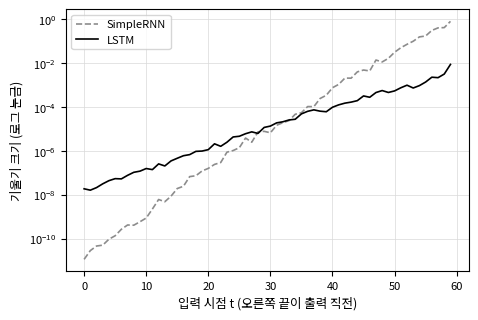

t=0까지 살아남는 비율 — SimpleRNN: 1.5e-11, LSTM: 2.2e-06


In [5]:
def grad_through_time(layer_cls, T=60, D=8):
    """마지막 출력의 기울기가 각 시점 입력까지
    얼마나 살아서 돌아가는지 측정한다."""
    tf.random.set_seed(11)
    x = tf.random.normal((1, T, D))
    layer, head = layer_cls(16), keras.layers.Dense(1)
    with tf.GradientTape() as tape:
        tape.watch(x)
        loss = tf.reduce_sum(head(layer(x)) ** 2)
    g = tape.gradient(loss, x)[0]
    return tf.norm(g, axis=1).numpy()

g_rnn = grad_through_time(keras.layers.SimpleRNN)
g_lstm = grad_through_time(keras.layers.LSTM)

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.semilogy(g_rnn, "--", color="#8c8c8c", lw=1.2,
            label="SimpleRNN")
ax.semilogy(g_lstm, "-", color="black", lw=1.2,
            label="LSTM")
ax.set_xlabel("입력 시점 t (오른쪽 끝이 출력 직전)")
ax.set_ylabel("기울기 크기 (로그 눈금)")
ax.legend()
plt.show()
print(f"t=0까지 살아남는 비율 — SimpleRNN: "
      f"{g_rnn[0] / g_rnn[-1]:.1e}, "
      f"LSTM: {g_lstm[0] / g_lstm[-1]:.1e}")

**핵심 포인트**(실행 검증 수치)
- SimpleRNN: 60스텝 전 입력에 도달하는 학습 신호가 마지막 스텝의 **10⁻¹¹ 배** — 사실상 소멸이다. 9장의 기울기 소실이 "시간축"에서 일어난 것(11.2 장기 의존성 문제).
- LSTM: 같은 거리에서 **10⁻⁶ 배** — 약 15만 배 더 살아남는다. 셀 상태를 곧장 통과하는 덧셈 경로(기울기 고속도로)의 효과다(11.2 LSTM 게이트).
- 이 측정은 학습 이전의 구조적 성질이라 시드만 고정하면 항상 같은 값이 재현된다.

실패 시 대처: 그래프가 뒤집혀 보이면 두 곡선의 라벨 순서를 확인한다. 값이 다르면 `tf.random.set_seed(11)`이 함수 안에 있는지 확인한다.

### [보조 1] SimpleRNN도 이 장난감 과제는 푼다 — 정직한 대조

In [6]:
def build_rnn(vocab=8):
    tf.random.set_seed(11)
    m = keras.Sequential([
        keras.layers.Embedding(vocab, 8),
        keras.layers.SimpleRNN(16),
        keras.layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])
    return m

rnn = build_rnn()
rnn.fit(X[:2400], y[:2400], epochs=15,
        batch_size=64, verbose=0)
acc_rnn = rnn.evaluate(X[2400:], y[2400:],
                       verbose=0)[1]
print(f"SimpleRNN gap=50 정확도: {acc_rnn:.0%}")
# 놀랍게도 성공한다! — 저장할 것이 "1비트"뿐이라
# 상태의 안정점에 새겨 넣을 수 있기 때문이다.
# 하지만 [셀 4]의 기울기 소멸은 그대로다: 기억할
# 것이 많아지고 시퀀스가 길어지는 실전(번역·문서)
# 에서는 이 소멸이 학습의 발목을 잡는다 — 그것이
# LSTM(11.2), 나아가 트랜스포머(11.3)의 존재 이유다.

SimpleRNN gap=50 정확도: 100%


E0000 00:00:1784199016.322304 153471574 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


### [심화 1] 한계 탐사 — gap을 늘려 보자 (연습문제 응용 연계)

In [7]:
# TODO: gap을 100, 150, 200으로 늘려 LSTM을 다시
#       학습시켜 보자. 어느 지점부터 학습이 불안정
#       해지는가(성공/실패가 시드에 따라 갈리는가)?
#       [셀 4]의 기울기 곡선과 연결해 해석해 보자.
# 힌트: 실패(≈50%)가 나오면 에폭을 늘리거나 시드를
#       바꿔 재시도 — "될 때도 있고 안 될 때도 있는"
#       불안정성 자체가 장기 의존성 문제의 실체다.
for gap in (100,):
    Xg, yg = make_data(gap)
    m = build_lstm()
    m.fit(Xg[:2400], yg[:2400], epochs=15,
          batch_size=64, verbose=0)
    a = m.evaluate(Xg[2400:], yg[2400:], verbose=0)[1]
    print(f"gap={gap}: 정확도 {a:.0%}")

gap=100: 정확도 50%


E0000 00:00:1784199024.782546 153471574 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


---
## 마무리

- 긴 의존성 과제의 두 가지 병목을 분리해서 봤다: **입력 창이 정보를 놓치는 문제**([셀 3] — 구조적 한계)와 **학습 신호가 시간을 거슬러 소멸하는 문제**([셀 4] — 기울기 소실).
- LSTM의 게이트·셀 상태는 두 번째 병목의 처방이다 — 기울기 보존이 십만 배 이상 개선되는 것을 측정으로 확인했다.
- 그러나 순서대로 하나씩 처리하는 구조 자체는 남는다 — "모든 시점을 한 번에 보는" 어텐션(11.3)이 다음 실습의 주제다.

**연습문제 연계**: [응용] 장기 의존성 실패 사례 분석은 [심화 1]의 탐사 기록으로 수행한다.

**다음 실습**: [실습 11-2] 어텐션 히트맵 (`lab-11-02_attention-heatmap.ipynb`)